# RTSP Input And Decode Options

This notebook explains the RTSP input side of a Neat application.

There are two useful RTSP API levels:

| API | What it gives you | Role |
| --- | --- | --- |
| `pyneat.nodes.rtsp_input(...)` | Raw RTSP/RTP source node. | When you want to manually build the depayload, parse, decode, or custom encoded pipeline. |
| `pyneat.groups.rtsp_decoded_input(options)` | A complete RTSP to decoded-frame graph fragment. | The decoded image-frame input path. |

For model pipelines, start with `RtspDecodedInputOptions`. It hides the RTSP receive, RTP depayload, H.264 parse, and hardware decode stages behind one graph fragment.

This notebook also introduces two runtime boundary concepts used with live streams:

| Concept | What it controls |
| --- | --- |
| `pyneat.OutputOptions` | Buffering and timing at a graph output endpoint. |
| `pyneat.RunOptions` | Runtime behavior for the whole built graph. |


## Imports

Run this notebook from the DevKit pyneat environment.


In [1]:
import cv2
import numpy as np
import pyneat
from IPython.display import Image, display


## Notebook Settings

Use a reachable RTSP URL from your camera or RTSP test server.


In [2]:
RTSP_URL = "rtsp://192.168.131.12:8555/stream"  # Replace with your RTSP source.
FALLBACK_WIDTH = 1280
FALLBACK_HEIGHT = 720
FALLBACK_FPS = 30
FRAMES_TO_PULL = 5


## Mental Model

A typical RTSP camera path looks like this:

```text
RTSP camera
  -> rtspsrc
  -> RTP H.264 depayloader
  -> H.264 parser
  -> H.264 hardware decoder
  -> raw video tensor, usually NV12
  -> model / overlay / encoder / output
```

`rtsp_input` is mostly the `rtspsrc` part. `rtsp_decoded_input` builds the whole front end through decoded raw frames.


## Low-Level RTSP Source

`pyneat.nodes.rtsp_input(...)` creates a source node for an RTSP stream. It is close to the network side of the pipeline: it receives RTSP/RTP data, but it does not decode frames by itself.

Arguments:

| Argument | Default | Meaning |
| --- | --- | --- |
| `url` | required | RTSP URL, for example `rtsp://host:8555/stream`. |
| `latency_ms` | `200` | Jitter buffer latency. Higher is more tolerant; lower is lower latency. |
| `tcp` | `True` | Use RTSP over TCP when true. TCP is often more reliable over networks/VPNs. |
| `drop_on_latency` | `False` | Drop late buffers when the jitter buffer cannot keep up. Useful for live latency control. |
| `buffer_mode` | `""` | Advanced RTSP source buffer mode; empty means default behavior. |

This node is useful when you want to manually compose the rest of the encoded-video path, such as depayload, parse, and decode nodes.


In [3]:
raw_graph = pyneat.Graph("raw_rtsp_source")
raw_graph.add(
    pyneat.nodes.rtsp_input(
        RTSP_URL,
        latency_ms=200,
        tcp=True,
        drop_on_latency=False,
        buffer_mode="",
    )
)
raw_graph.add(pyneat.nodes.output("rtsp_payload"))

print(raw_graph.describe())


0) RTSPInput  [rtsp://192.168.131.12:8555/stream]
1) Output  [rtsp_payload]


## Naming Note

In Python, the low-level RTSP source does not expose a separate `RtspInputOptions` class. Its configuration is passed directly as arguments to `pyneat.nodes.rtsp_input(...)`.

The decoded RTSP path does have an options class: `pyneat.RtspDecodedInputOptions`.


## Decoded RTSP Group

`pyneat.groups.rtsp_decoded_input(...)` creates a higher-level graph fragment for the common camera-input path.

Instead of stopping at the raw RTSP/RTP source, it builds the front end that an image/model pipeline normally needs:

```text
RTSP source -> RTP H.264 depayload -> H.264 parse -> SiMa H.264 decode -> raw decoded frame tensor
```

Use this group when the next stage expects image frames: model preprocessing, object detection, overlay, display, or video output.


## `pyneat.groups.rtsp_decoded_input(...)`

`pyneat.groups.rtsp_decoded_input(options)` takes a `pyneat.RtspDecodedInputOptions` object and returns a graph fragment. Add that fragment to a `pyneat.Graph` just like a node:

```python
graph.add(pyneat.groups.rtsp_decoded_input(rtsp_decode_options))
```

What this group controls:

| Part | Controlled by |
| --- | --- |
| RTSP URL and transport | `url`, `tcp`, `latency_ms`, `payload_type` |
| H.264 parser caps | `h264_*`, `fallback_h264_*`, `auto_caps_from_stream` |
| Hardware decode | `out_format`, `sima_allocator_type`, `decoder_*` |
| Optional adaptation | `use_videoconvert`, `use_videoscale` |
| Final raw output contract | `output_caps` |

What this group outputs:

| Output | Meaning |
| --- | --- |
| Decoded frame sample | A pullable `Sample` from the graph output node. |
| Raw video tensor | Usually NV12 when `out_format` and `output_caps.format` are NV12. |
| Frame metadata | Shape, width, height, image format, frame id, and timing fields when available. |

This is the main RTSP input API used by camera analytics examples.


## `RtspDecodedInputOptions`

`RtspDecodedInputOptions` configures the complete decoded RTSP input fragment.

Fields:

| Field | Meaning |
| --- | --- |
| `url` | RTSP URL to consume. |
| `latency_ms` | RTSP jitter-buffer latency in milliseconds. |
| `tcp` | Request RTSP-over-TCP when true; false allows UDP transport. |
| `payload_type` | RTP payload type for H.264, commonly `96`. |
| `h264_parse_config_interval` | SPS/PPS reinjection interval for H.264 parser; `-1` leaves default. |
| `h264_fps` | Explicit parser FPS caps; `-1` means unspecified. |
| `h264_width` | Explicit parser width caps; `-1` means unspecified. |
| `h264_height` | Explicit parser height caps; `-1` means unspecified. |
| `insert_queue` | Insert a queue inside the RTSP/decode fragment. |
| `sync_mode` | Use sync behavior for sinks when true; live analytics usually leave it false. |
| `auto_caps_from_stream` | Try to derive caps from the live stream automatically. |
| `fallback_h264_fps` | FPS used when stream caps cannot be detected. |
| `fallback_h264_width` | Width used when stream caps cannot be detected. |
| `fallback_h264_height` | Height used when stream caps cannot be detected. |
| `sima_allocator_type` | Decoder output allocator selector. Keep default unless a pipeline requires otherwise. |
| `out_format` | Decoder output pixel format, commonly `NV12`. |
| `decoder_name` | Optional stable decoder element name for diagnostics. |
| `decoder_raw_output` | Request decoded raw video output. |
| `decoder_next_element` | Optional decoder target hint such as `CVU` or `APU`. |
| `use_videoconvert` | Insert `videoconvert` after decode when format conversion is required. |
| `use_videoscale` | Insert `videoscale` after decode when resize/caps adaptation is required. |
| `output_caps` | Optional final caps filter for format, size, FPS, and memory. |
| `extra_fragment` | Advanced raw fragment inserted into the group. Avoid it in tutorials unless needed. |


In [4]:
decoded_options = pyneat.RtspDecodedInputOptions()
print("RtspDecodedInputOptions fields:")
print([name for name in dir(decoded_options) if not name.startswith("__")])
print()
print("output_caps fields:")
print([name for name in dir(decoded_options.output_caps) if not name.startswith("__")])


RtspDecodedInputOptions fields:
['auto_caps_from_stream', 'decoder_name', 'decoder_next_element', 'decoder_raw_output', 'extra_fragment', 'fallback_h264_fps', 'fallback_h264_height', 'fallback_h264_width', 'h264_fps', 'h264_height', 'h264_parse_config_interval', 'h264_width', 'insert_queue', 'latency_ms', 'out_format', 'output_caps', 'payload_type', 'sima_allocator_type', 'sync_mode', 'tcp', 'url', 'use_videoconvert', 'use_videoscale']

output_caps fields:
['enable', 'format', 'fps', 'height', 'memory', 'width']


## `output_caps` Suboptions

`output_caps` is useful when you want the decoded input fragment to advertise a deterministic raw frame contract.

| Field | Meaning |
| --- | --- |
| `enable` | Add a final caps filter when true. |
| `format` | Output pixel format, for example `pyneat.Format.NV12`. |
| `width` | Output width; `-1` leaves it unspecified. |
| `height` | Output height; `-1` leaves it unspecified. |
| `fps` | Output frame rate; `-1` leaves it unspecified. |
| `memory` | Buffer memory domain, for example `pyneat.CapsMemory.SystemMemory` or `Any`. |


## Build A Decoded RTSP Options Object

This is the common setup for camera analytics. It asks the decoder group to output NV12 frames.


In [5]:
def make_rtsp_decode_options(url: str, width: int, height: int, fps: int):
    opt = pyneat.RtspDecodedInputOptions()
    opt.url = url  # RTSP camera/test source.
    opt.latency_ms = 200  # Jitter buffer latency in ms.
    opt.tcp = True  # Prefer reliable RTSP-over-TCP.
    opt.payload_type = 96  # Common dynamic RTP payload type for H.264.
    opt.h264_parse_config_interval = -1  # Keep parser default for SPS/PPS reinjection.
    opt.insert_queue = True  # Decouple source/decode stages.
    opt.sync_mode = False  # Keep pull-driven notebook behavior simple.
    opt.auto_caps_from_stream = True  # Prefer caps discovered from the stream.
    opt.fallback_h264_width = width  # Used when stream caps are missing.
    opt.fallback_h264_height = height  # Used when stream caps are missing.
    opt.fallback_h264_fps = fps  # Used when stream caps are missing.
    opt.out_format = pyneat.Format.NV12  # Decoder output format.
    opt.decoder_name = "decoder"  # Helpful name in backend diagnostics.
    opt.decoder_raw_output = True  # Emit raw decoded frames.
    opt.use_videoconvert = False  # Keep native NV12 unless conversion is needed.
    opt.use_videoscale = False  # Keep source size unless scaling is needed.

    opt.output_caps.enable = True  # Make the output contract explicit.
    opt.output_caps.format = pyneat.Format.NV12  # NV12 is efficient for video/model pipelines.
    opt.output_caps.width = width
    opt.output_caps.height = height
    opt.output_caps.fps = fps
    opt.output_caps.memory = pyneat.CapsMemory.SystemMemory
    return opt

rtsp_decode_options = make_rtsp_decode_options(
    RTSP_URL,
    FALLBACK_WIDTH,
    FALLBACK_HEIGHT,
    FALLBACK_FPS,
)
print("url:", rtsp_decode_options.url)
print("output format:", rtsp_decode_options.output_caps.format)


url: rtsp://192.168.131.12:8555/stream
output format: Format.NV12


In [6]:
def public_names(obj):
    out = [name for name in dir(obj) if not name.startswith("_")]
    return out, len(out)

print("RtspDecodedInputOptions:")
print(public_names(rtsp_decode_options))
print()
print("RtspDecodedInputOptions - output_caps:")
print(public_names(rtsp_decode_options.output_caps))

RtspDecodedInputOptions:
(['auto_caps_from_stream', 'decoder_name', 'decoder_next_element', 'decoder_raw_output', 'extra_fragment', 'fallback_h264_fps', 'fallback_h264_height', 'fallback_h264_width', 'h264_fps', 'h264_height', 'h264_parse_config_interval', 'h264_width', 'insert_queue', 'latency_ms', 'out_format', 'output_caps', 'payload_type', 'sima_allocator_type', 'sync_mode', 'tcp', 'url', 'use_videoconvert', 'use_videoscale'], 23)

RtspDecodedInputOptions - output_caps:
(['enable', 'format', 'fps', 'height', 'memory', 'width'], 6)


## `pyneat.OutputOptions`

`pyneat.nodes.output(...)` creates the public pull endpoint for a graph. `OutputOptions` controls buffering and timing behavior at that endpoint.

Common presets:

| Preset | Meaning | Typical use |
| --- | --- | --- |
| `pyneat.OutputOptions.every_frame(max_buffers=30)` | Keep a bounded queue so the application can pull every produced sample. | Debugging, frame-by-frame tutorials, correctness checks. |
| `pyneat.OutputOptions.latest()` | Keep only the newest sample and drop older queued samples. | Lowest-latency live preview/analytics. |
| `pyneat.OutputOptions.clocked(max_buffers=1)` | Sync output to the pipeline clock. | Outputs that should be paced to realtime. |

Fields if you configure it manually:

| Field | Meaning |
| --- | --- |
| `max_buffers` | Maximum queued samples. `0` means unbounded. |
| `drop` | Drop old samples on overflow instead of blocking. |
| `sync` | Pace samples to the pipeline clock when true. |
| `combine_policy` | How a named output combines multiple producers, such as `ByFrame` or `ByPts`. |

For this notebook we use `every_frame(1)` so the output endpoint is simple and bounded while we pull a few decoded frames.


In [7]:
frame_output_options = pyneat.OutputOptions.every_frame(1)
print("max_buffers:", frame_output_options.max_buffers)
print("drop:", frame_output_options.drop)
print("sync:", frame_output_options.sync)
print("combine_policy:", frame_output_options.combine_policy)


max_buffers: 1
drop: False
sync: False
combine_policy: CombinePolicy.None_


## Build The Decoded RTSP Graph

The graph contains one decoded input group and one output node. Pulling from this graph gives decoded frame samples.


In [8]:
decoded_graph = pyneat.Graph("decoded_rtsp_input")
decoded_graph.add(pyneat.groups.rtsp_decoded_input(rtsp_decode_options))
decoded_graph.add(pyneat.nodes.output("frame", frame_output_options))

print(decoded_graph.describe())


0) RTSPInput  [rtsp://192.168.131.12:8555/stream]
1) Queue
2) H264Depacketize
3) Queue
4) H264CapsFixup
5) H264Decode
6) CapsRaw
7) Output  [frame]


## Run Options For Live RTSP

`RunOptions` controls how the graph behaves after it is built. For live streams, the important idea is latency control: if the notebook cannot consume every frame, it should keep the newest frame instead of building a queue of stale frames.

| Option | Use here | Why |
| --- | --- | --- |
| `preset` | `RunPreset.Realtime` | Choose realtime-oriented scheduling defaults. |
| `queue_depth` | `3` | Keep only a small live buffer. |
| `overflow_policy` | `KeepLatest` | Drop stale frames when the app is slower than the stream. |
| `output_memory` | `Owned` | Pull frames into memory the application can safely inspect/copy. |

A later notebook can go deeper into `RunOptions`; here we use the common RTSP live-stream setup.


In [9]:
run_options = pyneat.RunOptions()
run_options.preset = pyneat.RunPreset.Realtime
run_options.queue_depth = 3
run_options.overflow_policy = pyneat.OverflowPolicy.KeepLatest
run_options.output_memory = pyneat.OutputMemory.Owned

print("RunOptions ready")


RunOptions ready


## OutputOptions vs RunOptions

These two option objects work at different levels.

```text
graph.add(pyneat.nodes.output("frame", output_options))
    -> controls the graph output endpoint

run = graph.build(run_options)
    -> controls the whole running graph
```

| Option object | Applied at | Controls |
| --- | --- | --- |
| `OutputOptions` | `pyneat.nodes.output(...)` | How samples are buffered, dropped, clocked, or combined at that one output endpoint. |
| `RunOptions` | `graph.build(...)` | How the graph runtime schedules queues, handles overflow, and exposes output memory. |

In this notebook:

```python
frame_output_options = pyneat.OutputOptions.every_frame(1)
run_options.overflow_policy = pyneat.OverflowPolicy.KeepLatest
```

That means the output endpoint is small and bounded, while the whole live graph prefers fresh frames if the notebook falls behind.


## Pull A Few Decoded Frames

Run this cell only when `RTSP_URL` points to a reachable stream from the DevKit. The output tensor is usually NV12 with image metadata.


In [10]:
last_decoded_tensor = None

run = decoded_graph.build(run_options)
try:
    for frame_index in range(FRAMES_TO_PULL):
        sample = run.pull("frame", 5000)
        if sample is None:
            print("timeout waiting for RTSP frame")
            break
        tensors = list(getattr(sample, "tensors", []))
        if not tensors and getattr(sample, "tensor", None) is not None:
            tensors = [sample.tensor]
        if not tensors:
            print("frame", frame_index, "has no tensor payload")
            continue
        tensor = tensors[0]
        last_decoded_tensor = tensor
        print(
            "frame", frame_index,
            "shape", tuple(tensor.shape),
            "is_nv12", tensor.is_nv12(),
            "width", tensor.width(),
            "height", tensor.height(),
        )
finally:
    run.close()


[1/4] Initializing runtime...
[2/4] Building graph...
[3/4] Starting pipeline...
[4/4] Graph ready (2113 ms)
Pipeline:
rtspsrc name=n0_rtspsrc_2 location="rtsp://192.168.131.12:8555/stream" latency=200 protocols=tcp ! queue name=n1_queue_2 ! capsfilter name=n2_rtp_caps_2 caps="application/x-rtp,media=video,encoding-name=H264,payload=96" ! rtph264depay name=n2_depay_2 wait-for-keyframe=true ! identity name=n2_h264_segment_2 silent=true single-segment=true ! h264parse name=n2_h264parse_2 disable-passthrough=true ! capsfilter name=n2_h264_caps_2 caps="video/x-h264,parsed=true,stream-format=(string)byte-stream,alignment=(string)au" ! queue name=n3_queue_2 ! identity name=n4_h264_capsfix_2 silent=true ! neatdecoder name=decoder_2 sima-allocator-type=2 op-buff-name=decoder_2 dec-fmt=NV12 dec-width=1280 dec-height=720 dec-fps=30 ! capsfilter name=n6_caps_2 caps="video/x-raw(memory:SystemMemory),format=NV12,width=1280,height=720,framerate=30/1" ! appsink name=mysink_2 emit-signals=false sync=f

frame 0 shape (720, 1280) is_nv12 True width 1280 height 720
frame 1 shape (720, 1280) is_nv12 True width 1280 height 720
frame 2 shape (720, 1280) is_nv12 True width 1280 height 720
frame 3 shape (720, 1280) is_nv12 True width 1280 height 720
frame 4 shape (720, 1280) is_nv12 True width 1280 height 720


## Display The Last Decoded Frame

The decoded graph outputs video tensors. For notebook display, convert the last decoded tensor into an RGB image and render it inline.

If the output format is NV12, the helper reads the Y and UV payload and converts it to RGB with OpenCV. If the output is already a dense image tensor, it falls back to `to_numpy(copy=True)`.


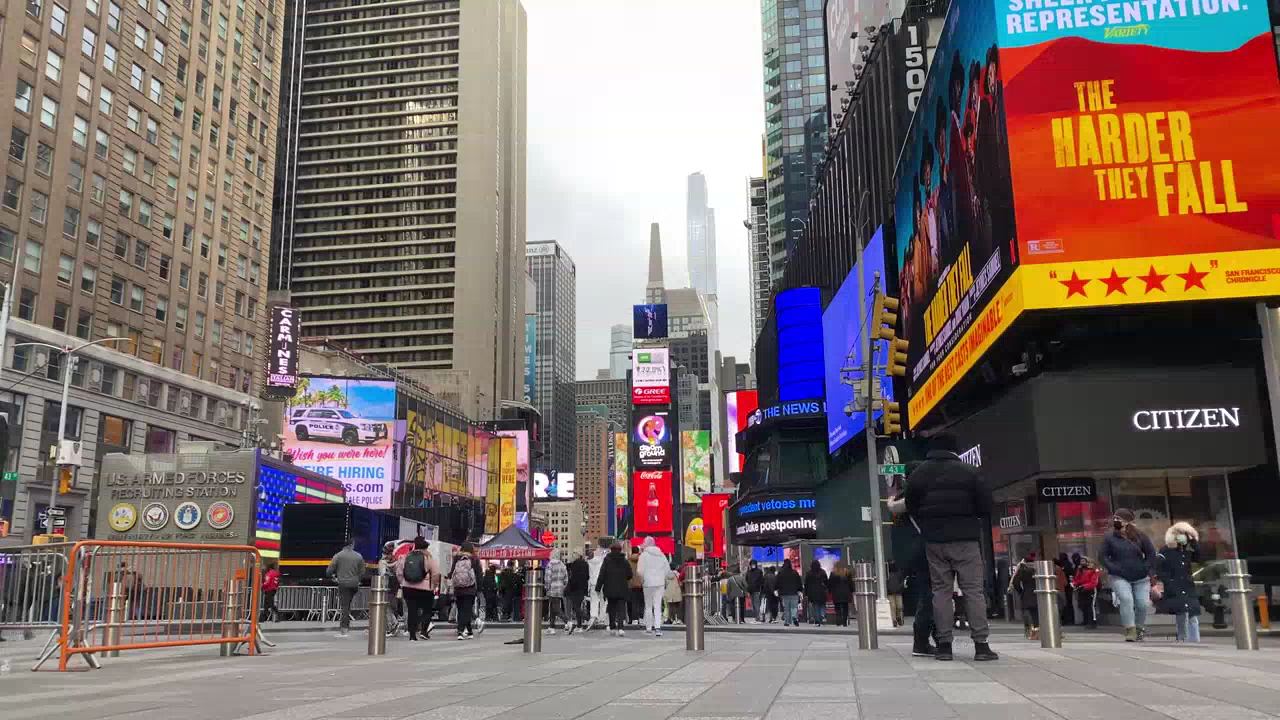

In [11]:
def tensor_dim(tensor, name: str) -> int:
    value = getattr(tensor, name)
    return int(value() if callable(value) else value)


def decoded_tensor_to_rgb(tensor):
    if tensor is None:
        return None
    if tensor.is_nv12():
        width = tensor_dim(tensor, "width")
        height = tensor_dim(tensor, "height")
        payload = np.frombuffer(tensor.copy_payload_bytes(), dtype=np.uint8)
        expected = width * height * 3 // 2
        nv12 = payload[:expected].reshape((height * 3 // 2, width))
        return cv2.cvtColor(nv12, cv2.COLOR_YUV2RGB_NV12)

    frame = np.asarray(tensor.to_numpy(copy=True))
    if frame.ndim == 4 and frame.shape[0] == 1:
        frame = frame[0]
    if frame.ndim == 2:
        return cv2.cvtColor(frame.astype(np.uint8), cv2.COLOR_GRAY2RGB)
    if frame.ndim == 3 and frame.shape[2] == 3:
        return frame.astype(np.uint8)
    raise RuntimeError(f"Unsupported decoded tensor shape for display: {frame.shape}")


last_frame_rgb = decoded_tensor_to_rgb(last_decoded_tensor)
if last_frame_rgb is None:
    print("No decoded frame available. Run the pull cell with a reachable RTSP stream first.")
else:
    ok, encoded = cv2.imencode(".png", cv2.cvtColor(last_frame_rgb, cv2.COLOR_RGB2BGR))
    if not ok:
        raise RuntimeError("Could not encode decoded frame for display")
    display(Image(data=encoded.tobytes()))


## Common Recipes

### Reliable Camera Stream

Use TCP and moderate latency:

```python
opt.tcp = True
opt.latency_ms = 200
opt.auto_caps_from_stream = True
```

### Lower Latency Stream

Use smaller latency and drop old frames at the run-option level:

```python
opt.latency_ms = 50
run_options.overflow_policy = pyneat.OverflowPolicy.KeepLatest
```

### Deterministic NV12 Output

Set explicit output caps:

```python
opt.output_caps.enable = True
opt.output_caps.format = pyneat.Format.NV12
opt.output_caps.width = 1280
opt.output_caps.height = 720
opt.output_caps.fps = 30
```

### Convert After Decode

Only enable conversion/scaling when a downstream stage needs it:

```python
opt.use_videoconvert = True
opt.output_caps.format = pyneat.Format.RGB
```


## How To Choose

| Goal | API |
| --- | --- |
| Inspect or compose the raw RTSP source path | `pyneat.nodes.rtsp_input(...)` |
| Pull decoded frames from a camera | `pyneat.groups.rtsp_decoded_input(...)` |
| Feed RTSP frames into YOLO/analytics | `pyneat.groups.rtsp_decoded_input(...)` with NV12 output caps |
| Build a custom RTP/H.264 chain yourself | `pyneat.nodes.rtsp_input(...)` plus depay/parse/decode nodes |
| Optimize live latency | decoded group + realtime `RunOptions` + `KeepLatest` |


## Debugging Checklist

- If `pull()` times out, first verify the RTSP URL is reachable from the DevKit.
- If caps are missing, set `fallback_h264_width`, `fallback_h264_height`, and `fallback_h264_fps`.
- If model preprocessing expects NV12, keep `out_format` and `output_caps.format` as `NV12`.
- If a downstream stage expects RGB/BGR, enable `use_videoconvert` and set explicit output caps.
- Use `graph.describe()` to inspect logical graph nodes and `graph.describe_backend()` when you need backend pipeline details.


## What To Remember

- `rtsp_input` is the low-level source node; it does not by itself give you decoded image tensors.
- `pyneat.groups.rtsp_decoded_input(...)` builds the camera-to-decoded-frame graph fragment.
- `RtspDecodedInputOptions` describes RTSP transport, H.264 parser fallback caps, decoder output, and final output caps.
- `pyneat.OutputOptions` controls buffering at one graph output endpoint.
- `pyneat.RunOptions` controls runtime behavior for the whole built graph.
- For realtime analytics, NV12 is usually the best decode output format.
- `auto_caps_from_stream` is convenient, but fallback caps make notebooks and demos easier to reproduce.
- Queue and overflow policy are part of the RTSP story because stale frames are a latency bug in live pipelines.


## References

- Core RTSP tutorial: [consume_rtsp_stream.py](https://github.com/sima-neat/core/blob/main/tutorials/018_consume_rtsp_stream/consume_rtsp_stream.py)
- Core tutorials: [https://github.com/sima-neat/core/tree/main/tutorials](https://github.com/sima-neat/core/tree/main/tutorials)
- Apps examples: [https://github.com/sima-neat/apps/tree/main/examples](https://github.com/sima-neat/apps/tree/main/examples)
